In [ ]:
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Cargar el dataset
iris = load_iris()

In [ ]:
#Leer el dataset
data_df = pd.DataFrame(iris.data, columns=iris.feature_names)
data_df["target"] = iris.target

data_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
#Seleccionar columnas
columns = ["sepal length (cm)", "petal length (cm)", "target"]
data_df = data_df[columns]
data_df.tail(5)

,sepal length (cm),petal length (cm),target
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2
149,5.9,5.1,2


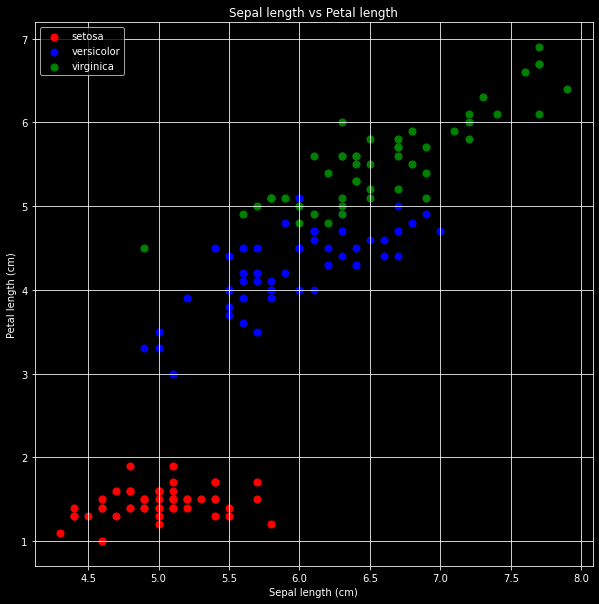

In [ ]:
#Visualizar datos
plt.figure(figsize=(10,10))
#Datos de iris setosa
setosa_data = data_df[data_df["target"] == 0]
#Datos de iris versicolor
versicolor_data = data_df[data_df["target"] == 1]
#Datos de iris virginica
virginica_data = data_df[data_df["target"] == 2]

#Graficar los datos
plt.scatter(setosa_data["sepal length (cm)"], setosa_data["petal length (cm)"], label="setosa", color="red", s=50)
plt.scatter(versicolor_data["sepal length (cm)"], versicolor_data["petal length (cm)"], label="versicolor", color="blue", s=50)
plt.scatter(virginica_data["sepal length (cm)"], virginica_data["petal length (cm)"], label="virginica", color="green", s=50)

plt.title("Sepal length vs Petal length")
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')

plt.grid()
plt.legend()
plt.show()


In [ ]:
#Obtenemos solo los valores de nuestro DataFrame
X = data_df[["sepal length (cm)", "petal length (cm)"]].values

y = data_df["target"].values


In [ ]:
#Dividir datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Entrenamos nuestro mlp
mlp = MLPClassifier(hidden_layer_sizes=(100), max_iter=300, activation='relu', random_state=42)
mlp.fit(X_train, y_train)

c:\Users\MSI\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=100, max_iter=300, random_state=42)

In [ ]:
#Predecir los datos del conjunto de prueba
y_pred = mlp.predict(X_test)
print(y_pred)
print(y_test)

[1 0 2 1 1 0 1 1 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [ ]:
#Calcular exactitud del modelo
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Exactitud: {accuracy:.2f}%")

Exactitud: 96.67%


In [ ]:
#Funciones de activación a evaluar
activations = ['logistic', 'tanh', 'relu']

#Diccionario para almacenar los resultados
results = {}

#Entrenar y evaluar el modelo con diferentes funciones de activación
for activation in activations:
    mlp = MLPClassifier(hidden_layer_sizes=(100,), activation=activation, max_iter=300, random_state=42)
    mlp.fit(X_train, y_train)

    y_pred = mlp.predict(X_test)


    #Calcular las métricas de rendimiento
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    #Almacenar los resultados
    results[activation] = {
        'accuracy' : accuracy,
        'classification_report' : report
    }


#Mostrar los resultados
for activation, metrics in results.items():
    print(f"Función de Activación: {activation}")
    print(f"Accuracy: {metrics['accuracy']}")
    print(f"Classification_report: \n{metrics['classification_report']}")
    print("-" * 60)

c:\Users\MSI\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\MSI\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Función de Activación: logistic
Accuracy: 1.0
Classification_report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------------------------------------------------------------
Función de Activación: tanh
Accuracy: 0.9666666666666667
Classification_report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

--------------------------

c:\Users\MSI\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
